# Environmental forcing versus total reconstructed PV

Keep the environmental vector as the forcing estimate, then test how much adding the eddy's own $\nabla\zeta/h$ changes the result.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import esp_pv_tools as ept
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}


In [2]:
data = ept.load_cache()
gaussian = data[data.pv_surface_method.eq("esp_gaussian")].copy()
focus=gaussian[gaussian.method.eq("esp_gaussian_2")].copy()
focus["full_environment_ratio"]=focus.PV_grad_full_mag/focus.PV_grad_mag
focus["full_direction_change"]=np.abs((focus.PV_grad_full_theta-focus.PV_grad_theta+180)%360-180)

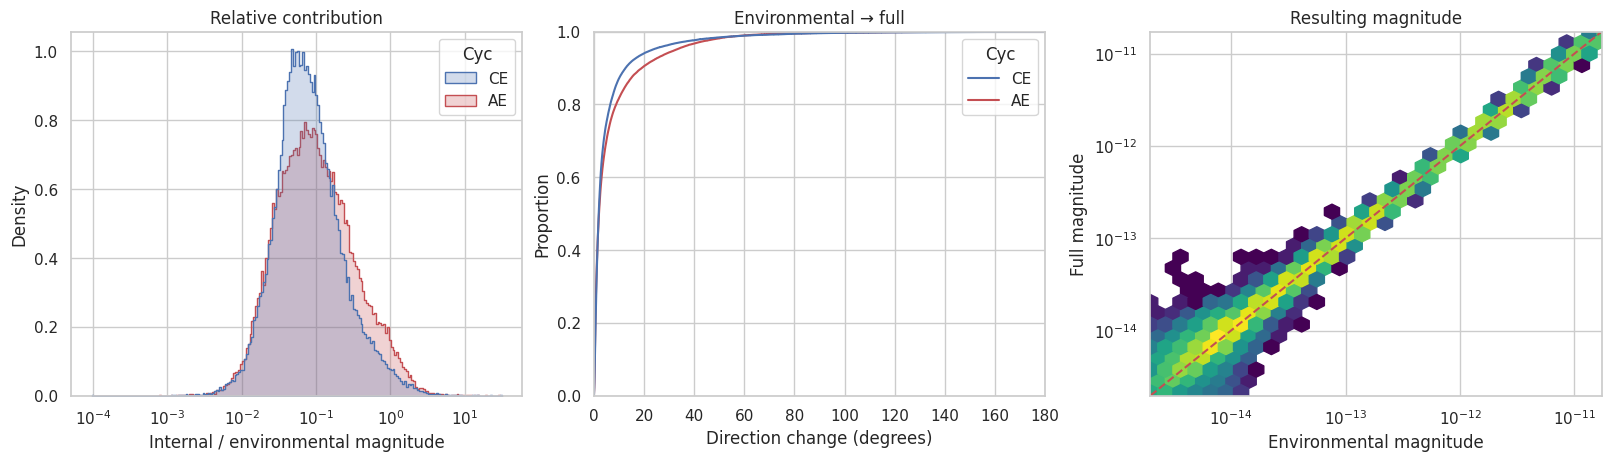

In [3]:
fig,axes=plt.subplots(1,3,figsize=(16,4.5),constrained_layout=True)
sns.histplot(data=focus,x="internal_environment_ratio",hue="Cyc",element="step",stat="density",common_norm=False,log_scale=True,palette=palette,ax=axes[0])
sns.ecdfplot(data=focus,x="full_direction_change",hue="Cyc",palette=palette,ax=axes[1])
hb=axes[2].hexbin(focus.PV_grad_mag,focus.PV_grad_full_mag,gridsize=45,mincnt=1,bins="log",xscale="log",yscale="log",cmap="viridis")
lims=np.nanpercentile(np.r_[focus.PV_grad_mag,focus.PV_grad_full_mag],[1,99]); axes[2].plot(lims,lims,"r--"); axes[2].set(xlim=lims,ylim=lims)
axes[0].set(xlabel="Internal / environmental magnitude",title="Relative contribution")
axes[1].set(xlim=(0,180),xlabel="Direction change (degrees)",title="Environmental → full")
axes[2].set(xlabel="Environmental magnitude",ylabel="Full magnitude",title="Resulting magnitude"); plt.show()

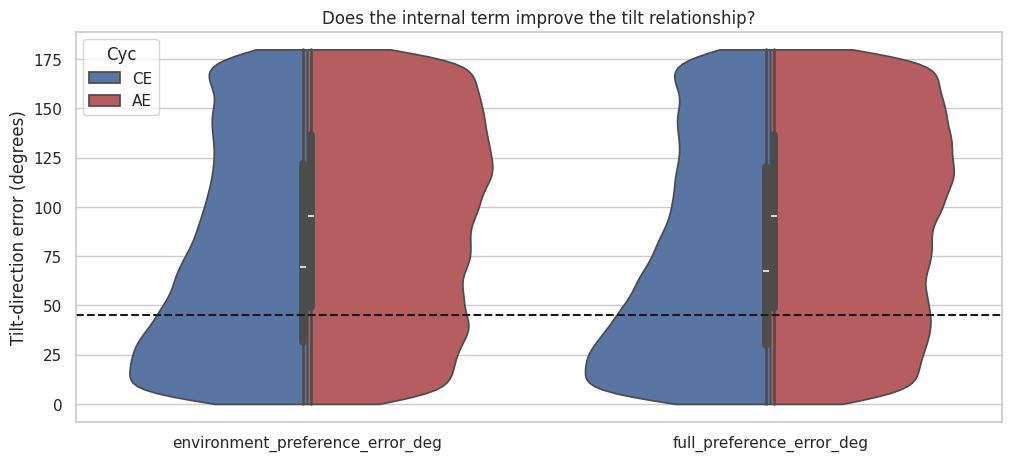

In [4]:
plot=focus.melt(id_vars=["Cyc"],value_vars=["environment_preference_error_deg","full_preference_error_deg"],var_name="vector",value_name="polarity_adjusted_error")
fig,ax=plt.subplots(figsize=(10,4.5),constrained_layout=True)
sns.violinplot(data=plot,x="vector",y="polarity_adjusted_error",hue="Cyc",split=True,cut=0,palette=palette,ax=ax)
ax.axhline(45,color="k",ls="--"); ax.set(xlabel="",ylabel="Tilt-direction error (degrees)",title="Does the internal term improve the tilt relationship?"); plt.show()